### Auto-Encoder 

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import random

In [2]:
labels = []
numbers = []

with open(os.path.join(os.getcwd(), 'data/MNISTnumLabels5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        labels.append(int(line))

with open(os.path.join(os.getcwd(), 'data/MNISTnumImages5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        ind_line = line.split('\t')
        ind_line = [float(i) for i in ind_line]

        numbers.append(ind_line)
    

labels = np.array(labels)
numbers = np.array(numbers)

6


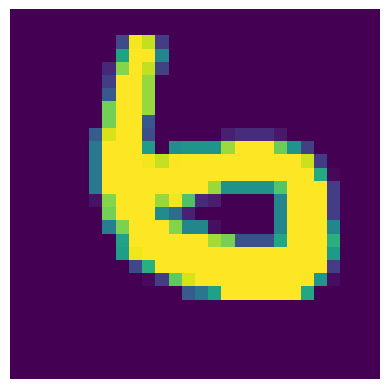

In [3]:
index = random.randint(0, 4999)

example_number = numbers[index]
example_label = labels[index]
matrix = example_number.reshape(28, 28).T

print(example_label)
plt.imshow(matrix)
plt.axis('off')
plt.show()

In [4]:
train_set = []
train_labels = []

test_set = []
test_labels = []

digits = {d: 0 for d in range(0, 10)}

for i in range(len(numbers)):
    label = labels[i]  # get the digit for this image
    
    if label in digits and digits[label] < 400:
        train_set.append(numbers[i])
        train_labels.append(label)
        digits[label] += 1
    else:
        test_set.append(numbers[i])
        test_labels.append(label)
        digits[label] += 1


train_set = np.array(train_set)
test_set = np.array(test_set)
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)
# normalizing the datasets
train_set = train_set.astype(np.float32)/255.0
test_set = test_set.astype(np.float32)/255.0

combined_train_data = list(zip(train_labels, train_set))
random.shuffle(combined_train_data)

combined_test_data = list(zip(test_labels, test_set))
random.shuffle(combined_test_data)

print(len(combined_train_data), len(combined_test_data))

4000 1000


In [5]:
m, n = train_set.shape

X_train, X_test = train_set, test_set
Y_train, Y_test = train_labels, test_labels

_, m_train = X_train.shape
_, m_test = X_test.shape

In [6]:
# Shuffle training set
perm_train = np.random.permutation(X_train.shape[0])  # columns = samples
X_train = X_train[perm_train]
Y_train = np.array(Y_train)[perm_train]  

# Shuffle test set
perm_test = np.random.permutation(X_test.shape[0])
X_test = X_test[perm_test]
Y_test = np.array(Y_test)[perm_test]

X_train.shape, Y_train.shape

((4000, 784), (4000,))

### Neural Network Implementation

In [131]:
class CustomNeuralNet:

    def __init__(self, layers, layer_sizes, momentum=0.9):
        self.layers = layers
        self.layer_sizes = layer_sizes
        self.momentum = momentum

        self.W = []
        self.b = []
        self.vW = []
        self.vb = []

        self.train_accuracy_over_epochs = []
        self.test_accuracy_over_epochs = []
        self.train_error_over_epochs = []
        self.test_error_over_epochs = []


        for i in range(self.layers - 1):
            in_size = layer_sizes[i]
            out_size = layer_sizes[i+1]

            W_i = np.random.randn(in_size, out_size) * 0.01
            b_i = np.zeros((1, out_size))

            self.W.append(W_i)
            self.b.append(b_i)

            self.vW.append(np.zeros_like(W_i))
            self.vb.append(np.zeros_like(b_i))

    
    ### Activation Functions
    def tanh(self, x):
        return np.tanh(x)
    
    def tanh_deriv(self, x):
        return 1 - np.tanh(x)**2

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
        
    def sigmoid_deriv(self, x):
        s = self.sigmoid(x)
        return s * (1 - s)

    
    ### Forward Pass
    def forward(self, x):
        A = x

        '''
        We store A and Z at every layer so that during backprop we can 
        compute gradients for weights, biases, and previous layers.
        '''
        A_cache = [A]
        Z_cache = []

        for i in range(self.layers - 1):
            Z = A @ self.W[i] + self.b[i]       # linear
            Z_cache.append(Z)

            # last layer only
            if i == self.layers - 2:
                A = Z
            else:
                A = self.tanh(Z)

            A_cache.append(A)

        return A, Z_cache, A_cache
    
    ### Back propogation
    def backward(self, Y, Z_cache, A_cache):
        m = Y.shape[0]

        dW = [None] * (self.layers - 1)
        db = [None] * (self.layers - 1)

        A_final = A_cache[-1]

        # dJ/dA for MSE loss
        dA = (A_final - Y)

        # Backprop through each layer
        for i in reversed(range(self.layers - 1)):
            A_prev = A_cache[i]

            if i == self.layers - 2:   # last layer
                dZ = dA 
            else:
                dZ = dA * self.tanh_deriv(Z_cache[i])

            dW[i] = (A_prev.T @ dZ) / m
            db[i] = np.sum(dZ, axis=0, keepdims=True) / m

            if i > 0:
                dA = dZ @ self.W[i].T

        return dW, db
    
    ### Momentum Update
    def update_params(self, dW, db, lr):
        for i in range(self.layers - 1):

            # update momentum buffers
            self.vW[i] = self.momentum * self.vW[i] - lr * dW[i]
            self.vb[i] = self.momentum * self.vb[i] - lr * db[i]

            # update parameters
            self.W[i] += self.vW[i]
            self.b[i] += self.vb[i]

    ### Model Training
    def train(self, X, Y, X_test, Y_test, epochs, lr, batch_size=64):
        n = X.shape[0]   # number of samples

        for epoch in range(epochs):

            perm = np.random.permutation(n)
            X = X[perm]
            Y = Y[perm]

            for i in range(0, n, batch_size):
                X_batch = np.array(X[i:i+batch_size])
                Y_batch = np.array(Y[i:i+batch_size])

                # Forward on this batch only
                A, Z_cache, A_cache = self.forward(X_batch)

                # Backprop on this batch only
                dW, db = self.backward(Y_batch, Z_cache, A_cache)

                # Update
                self.update_params(dW, db, lr)
            
            if epoch % 10 == 0:
                train_loss = self.reconstruction_loss(X, Y)
                test_loss  = self.reconstruction_loss(X_test, Y_test)

                self.train_error_over_epochs.append(train_loss)
                self.test_error_over_epochs.append(test_loss)

                print(f"Epoch {epoch} | Training MRL: {train_loss:.6f}")

    def predict(self, X, show=False):
        A, _, _ = self.forward(X)

        return A
    
    def reconstruction_loss(self, X, Y):
        A = self.predict(X)  # reconstructed output
        diff = A - Y

        # 1/2 * 1/784 * sum((x_i - y_i)^2) averaged over data
        J_per_sample = 0.5 * np.mean(diff**2, axis=1)

        return np.mean(J_per_sample)


    def reconstruction_accuracy(self, X, Y, tol=0.1):
        A = self.predict(X)
        correct_pixels = np.abs(A - Y) < tol
        return np.mean(correct_pixels)


    def plot_accuracy_over_epochs(self):
        epochs = list(range(len(self.train_accuracy_over_epochs)))

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, self.train_accuracy_over_epochs, label="Train Accuracy")
        plt.plot(epochs, self.test_accuracy_over_epochs, label="Test Accuracy")

        plt.title("Accuracy Over Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")

        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()

    def plot_error_over_epochs(self):
        epochs = np.arange(len(self.train_error_over_epochs))

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, self.train_error_over_epochs, label="Training Error")
        plt.plot(epochs, self.test_error_over_epochs, label="Test Error")

        plt.title("Error Fraction Over Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Error Fraction")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def confusion_matrix(self, X, Y):
        num_classes = self.layer_sizes[-1]   # should be 10 for MNIST
        cm = np.zeros((num_classes, num_classes), dtype=int)

        predictions = self.predict(X)  # shape (m,)
        
        for true, pred in zip(Y, predictions):
            cm[int(true), int(pred)] += 1

        return cm

### Applying the nn on the dataset

In [130]:
ae = CustomNeuralNet(layers=3, layer_sizes=[784, 128, 784])

ae.train(X=X_train, Y=X_train, X_test=X_test, Y_test=X_test, epochs=200, lr=0.001, batch_size=100)

Epoch 0 | Training MRL: 0.000001
Epoch 10 | Training MRL: 0.000000
Epoch 20 | Training MRL: 0.000000


KeyboardInterrupt: 

In [104]:
ae.reconstruction_accuracy(X_test, X_test, tol=0.007)

0.12697831632653062

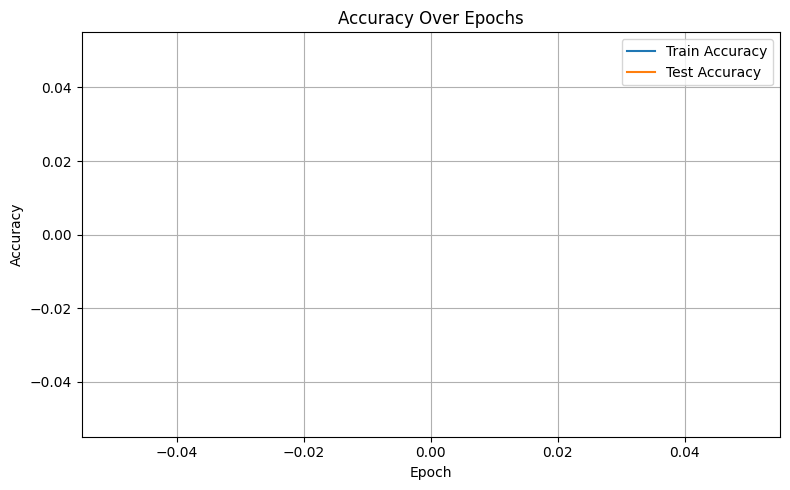

In [60]:
ae.plot_accuracy_over_epochs()

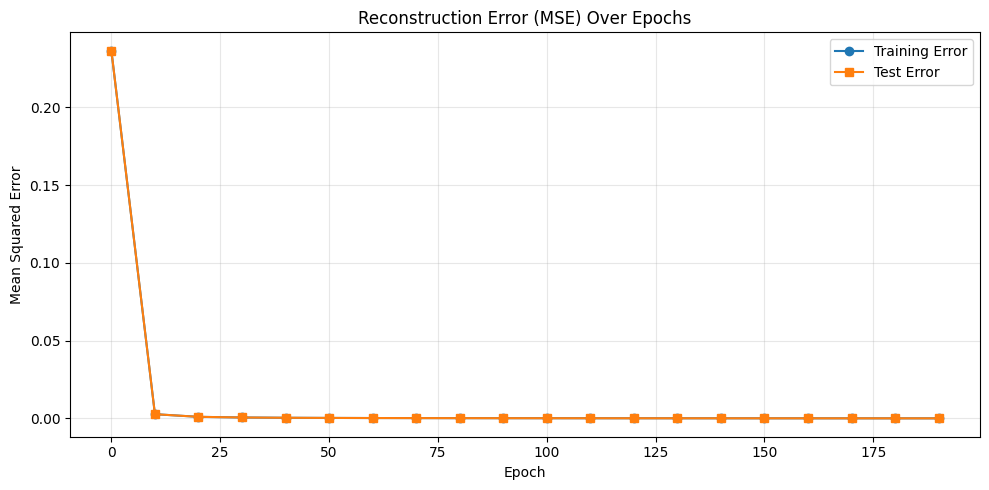

In [118]:
ae.plot_error_over_epochs()

In [ ]:
train_cm = ae.confusion_matrix(X_train, Y_train)
test_cm = ae.confusion_matrix(X_test, Y_test)

print("Training Confusion Matrix:\n", train_cm)
print("Test Confusion Matrix:\n", test_cm)

Training Confusion Matrix:
 [[375   0   1   2   1   6   6   2   6   1]
 [  0 378   6   1   1   0   4   1   9   0]
 [  6   4 337   8   2   0   6  17  17   3]
 [  2   3  11 330   2   7   4  19  16   6]
 [  2   5   1   0 313   2   7   6  10  54]
 [ 10   6   1  23   6 285  11  15  38   5]
 [ 10   5   2   1   3   7 368   1   3   0]
 [  3  14   8   2   6   1   2 341   4  19]
 [  5  14   7  12   3   5   7   4 340   3]
 [  4   6   1   6   7   0   1  26  10 339]]
Test Confusion Matrix:
 [[94  0  0  0  0  2  3  0  1  0]
 [ 0 93  2  1  0  0  0  1  2  1]
 [ 2  3 82  3  1  0  1  4  4  0]
 [ 0  0  6 81  0  2  0  4  5  2]
 [ 0  3  1  0 67  0  4  1  2 22]
 [ 3  2  1  3  1 74  2  3 10  1]
 [ 3  0  2  0  0  2 93  0  0  0]
 [ 0  2  3  2  1  0  1 86  0  5]
 [ 1  1  1  3  2  1  4  4 79  4]
 [ 1  1  0  1  3  1  0  7  0 86]]


In [ ]:
ae.accuracy(X_train, X_train)

0.8515

8


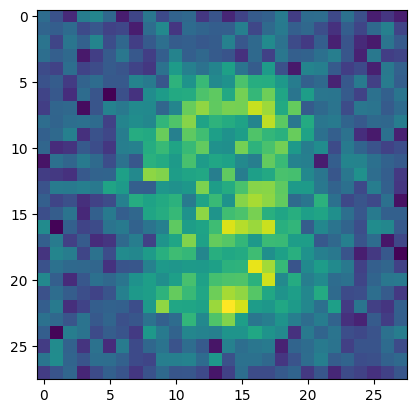

In [128]:
index = random.randint(0, 999)
A = ae.predict(X_test[index])
print(Y_test[index])
plt.imshow(A.reshape(28,28).T)
plt.show()

In [ ]:
np.savez("ae_model_weights.npz", W1=ae.W[0], b1=ae.b[0], W2=ae.W[1], b2=ae.b[1])

In [ ]:
data = np.load("ae_model_weights.npz")
W1_copy = data["W1"]
b1_copy = data["b1"]
W2_copy = data["W2"]
b2_copy = data["b2"]

nn.W[0] == W1_copy

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])